# Assignment 1 2AMM10 2025-2026

## Group: no
### Member 1: Ana Sirbu
### Member 2: Carina Ungureanu
### Member 3: Alexia Dragomirescu

## Task 1 

Dataset and visualization

In [1]:
import os
import re
from pathlib import Path
from torch.utils.data import Dataset
from PIL import Image
import kagglehub
import torch
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

class AppleDataset(Dataset):
    def __init__(self, transform=None, subset="train",class_subset = "main"):
        assert subset in ["train","test"]
        assert class_subset in ["main","new","all"]
        path = kagglehub.dataset_download("moltean/fruits")
        base = Path(path) / "fruits-360_original-size" / "fruits-360-original-size"
        if subset == "train":
            self.path = base / "Training"
        elif subset == "test":
            self.path = base / "Validation"
        self.transform = transform
        all_folders = sorted(os.listdir(self.path))
        self.item_folders = sorted(x for x in all_folders if x.lower().startswith("apple"))
        generator=np.random.default_rng(6)
        generator.shuffle(self.item_folders)
        if class_subset == "main":
            self.item_folders = self.item_folders[:20]
        elif class_subset == "new":
            self.item_folders = self.item_folders[20:]
        self.targets = []
        self.image_paths = []
        for i, folder in enumerate(self.item_folders):
            for img_file in sorted(os.listdir(self.path / folder)):
                if img_file.startswith("r0"):
                    if class_subset=="new":
                        self.targets.append(i+20)
                    else: 
                        self.targets.append(i)
                    self.image_paths.append(self.path / folder / img_file)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, i):
        image = Image.open(self.image_paths[i]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, self.targets[i]

dataset = AppleDataset()

item_dd = widgets.Dropdown(options=dataset.item_folders, description="Variety:")
frame_slider = widgets.IntSlider(value=0, min=0, max=0, description="Frame:")
output = widgets.Output()


def get_frames(folder):
    return sorted(f for f in os.listdir(dataset.path / folder)
                  if f.startswith("r0_") and f.endswith(".jpg"))

def update_slider(*_):
    frames = get_frames(item_dd.value)
    frame_slider.max = max(0, len(frames) - 1)
    frame_slider.value = min(frame_slider.value, frame_slider.max)
    show_image()

def show_image(*_):
    frames = get_frames(item_dd.value)
    if not frames or frame_slider.value >= len(frames):
        return
    with output:
        clear_output(wait=True)
        img = Image.open(dataset.path / item_dd.value / frames[frame_slider.value])
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(img)
        ax.set_title(f"{item_dd.value} | frame {frame_slider.value}")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

item_dd.observe(update_slider, names="value")
frame_slider.observe(show_image, names="value")

update_slider()
display(widgets.VBox([item_dd, frame_slider, output]))

In [2]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
train_data = AppleDataset(subset="train",transform=transform)
test_data = AppleDataset(subset="test",transform=transform)
support_new_data = AppleDataset(subset="train",transform=transform,class_subset="new")
test_new_data = AppleDataset(subset="test",transform=transform,class_subset="new")

In [3]:
import torch
print(torch.cuda.is_available())    # True
print(torch.version.cuda)           # 12.4
#print(torch.cuda.get_device_name(0)) # your GPU name

False
None


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import models
from collections import defaultdict
import random

# --- Model ---
class EmbeddingCNN(nn.Module):
    def __init__(self, embed_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),       
            nn.Flatten(),
            nn.Linear(128, embed_dim)      
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=1) 

# --- Triplet Dataset (unchanged, correct) ---
class TripletDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        self.class_to_indices = defaultdict(list)
        for idx, label in enumerate(dataset.targets):
            self.class_to_indices[label].append(idx)
        self.classes = list(self.class_to_indices.keys())

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        anchor, label = self.dataset[idx]
        pos_idx = idx
        while pos_idx == idx:
            pos_idx = random.choice(self.class_to_indices[label])
        positive, _ = self.dataset[pos_idx]
        neg_label = random.choice([c for c in self.classes if c != label])
        negative, _ = self.dataset[random.choice(self.class_to_indices[neg_label])]
        return anchor, positive, negative

# --- Training ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EmbeddingCNN(embed_dim=128).to(device)
criterion = nn.TripletMarginLoss(margin=0.5, swap=True) 
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

loader = DataLoader(TripletDataset(train_data), batch_size=32, shuffle=True)

for epoch in range(15):
    model.train()
    total_loss = 0
    for a, p, n in loader:
        a, p, n = a.to(device), p.to(device), n.to(device)
        loss = criterion(model(a), model(p), model(n))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1:2d} | loss: {total_loss/len(loader):.4f}")

    # --- Evaluation ---
def get_embeddings(model, dataset):
    model.eval()
    embs, labels = [], []
    with torch.no_grad():
        for imgs, lbls in DataLoader(dataset, batch_size=64):
            embs.append(model(imgs.to(device)).cpu())
            labels.extend(lbls.tolist())
    return torch.cat(embs), labels

def nn_accuracy(query_embs, query_labels, gallery_embs, gallery_labels, exclude_self=False):
    dists = torch.cdist(query_embs, gallery_embs)
    if exclude_self:
        dists.fill_diagonal_(float('inf'))  # mask self-matches
    preds = [gallery_labels[i] for i in dists.argmin(dim=1).tolist()]
    correct = sum(p == q for p, q in zip(preds, query_labels))
    return correct / len(query_labels)

# --- Get embeddings ---
train_embs,    train_labels    = get_embeddings(model, train_data)
test_embs,     test_labels     = get_embeddings(model, test_data)
support_embs,  support_labels  = get_embeddings(model, support_new_data)
test_new_embs, test_new_labels = get_embeddings(model, test_new_data)

known_acc = nn_accuracy(test_embs, test_labels, train_embs, train_labels)
new_acc = nn_accuracy(test_new_embs, test_new_labels, support_embs, support_labels)

print(f"Known (test vs train) Accuracy: {known_acc:.4f}")
print(f"New (test vs support) Accuracy: {new_acc:.4f}")

Epoch  1 | loss: 0.0775
Epoch  2 | loss: 0.0281
Epoch  3 | loss: 0.0153
Epoch  4 | loss: 0.0130
Epoch  5 | loss: 0.0068
Epoch  6 | loss: 0.0073
Epoch  7 | loss: 0.0039
Epoch  8 | loss: 0.0064
Epoch  9 | loss: 0.0046
Epoch 10 | loss: 0.0034
Epoch 11 | loss: 0.0015
Epoch 12 | loss: 0.0019
Epoch 13 | loss: 0.0012
Epoch 14 | loss: 0.0028
Epoch 15 | loss: 0.0030
Known (test vs train) Accuracy: 0.9480
New (test vs support) Accuracy: 0.9040


## Task 2

In [7]:
class GardenDataset(Dataset):
    def __init__(self, transform=None, class_level="item", subset="train", family_subset="main", item_subset="main"):
        assert class_level in ["item","family","both"]
        assert subset in ["train","test"]
        assert family_subset in ["main","new","all"]
        assert item_subset in ["main","new","all"]
        path = kagglehub.dataset_download("moltean/fruits")
        base = Path(path) / "fruits-360_original-size" / "fruits-360-original-size"
        if subset == "train":
            self.path = base / "Training"
        elif subset == "test":
            self.path = base / "Validation"
        self.transform = transform
        self.class_level = class_level

        canonical_items = sorted(
            d for d in os.listdir(base / "Training")
            if (base / "Training" / d).is_dir() and re.fullmatch(r'\S+ \d+', d)
        )
        item_to_family = {it: it.rsplit(' ', 1)[0] for it in canonical_items}
        canonical_families = sorted(set(item_to_family.values()))

        self.item_to_idx = {c: i for i, c in enumerate(canonical_items)}
        self.family_to_idx = {c: i for i, c in enumerate(canonical_families)}

        train_fam_to_items = defaultdict(list)
        for it in canonical_items:
            train_fam_to_items[item_to_family[it]].append(it)
        for fam in train_fam_to_items:
            train_fam_to_items[fam].sort(key=lambda x: int(x.rsplit(' ', 1)[1]))

        new_families = {fam for fam, its in train_fam_to_items.items() if len(its) == 1}
        new_items = set()
        for fam, its in train_fam_to_items.items():
            if len(its) >= 3:
                new_items.add(its[0]) 

        present = {
            d for d in os.listdir(self.path)
            if (self.path / d).is_dir() and re.fullmatch(r'\S+ \d+', d)
        }
        all_items = [it for it in canonical_items if it in present]

        if family_subset == "main":
            all_items = [it for it in all_items if item_to_family[it] not in new_families]
        elif family_subset == "new":
            all_items = [it for it in all_items if item_to_family[it] in new_families]

        if item_subset == "main":
            all_items = [it for it in all_items if it not in new_items]
        elif item_subset == "new":
            all_items = [it for it in all_items if it in new_items]

        self.items = all_items
        self.item_to_family = {it: item_to_family[it] for it in self.items}
        self.families = sorted(set(self.item_to_family.values()))
        self.new_families = new_families
        self.new_items = new_items

        # Build samples using canonical (global) indices
        self.image_paths = []
        self.targets_item = []
        self.targets_family = []
        for item in self.items:
            item_dir = self.path / item
            item_label = self.item_to_idx[item]
            family_label = self.family_to_idx[item_to_family[item]]
            for img_file in sorted(os.listdir(item_dir)):
                if img_file.endswith('.jpg'):
                    self.image_paths.append(item_dir / img_file)
                    self.targets_item.append(item_label)
                    self.targets_family.append(family_label)

        if class_level == "item":
            self.classes = self.items
            self.class_to_idx = self.item_to_idx
            self.targets = self.targets_item
        elif class_level == "family":
            self.classes = self.families
            self.class_to_idx = self.family_to_idx
            self.targets = self.targets_family

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        if self.class_level == "both":
             return image, self.targets_family[idx], self.targets_item[idx]
        return image, self.targets[idx]

    def get_items_for_family(self, family):
        return sorted(item for item, fam in self.item_to_family.items() if fam == family)

dataset = GardenDataset()

family_dd = widgets.Dropdown(options=dataset.families, description="Family:")
item_dd = widgets.Dropdown(options=dataset.get_items_for_family(dataset.families[0]), description="Item:")
frame_slider = widgets.IntSlider(value=0, min=0, max=0, description="Frame:")
output = widgets.Output()


def get_frames(item):
    return sorted(f for f in os.listdir(dataset.path / item) if f.endswith(".jpg"))

def update_items(*_):
    items = dataset.get_items_for_family(family_dd.value)
    item_dd.options = items
    item_dd.value = items[0]

def update_slider(*_):
    frames = get_frames(item_dd.value)
    frame_slider.max = max(0, len(frames) - 1)
    frame_slider.value = min(frame_slider.value, frame_slider.max)
    show_image()

def show_image(*_):
    frames = get_frames(item_dd.value)
    if not frames or frame_slider.value >= len(frames):
        return
    with output:
        clear_output(wait=True)
        img = Image.open(dataset.path / item_dd.value / frames[frame_slider.value])
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(img)
        ax.set_title(f"{family_dd.value} | {item_dd.value} | frame {frame_slider.value}")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

family_dd.observe(update_items, names="value")
item_dd.observe(update_slider, names="value")
frame_slider.observe(show_image, names="value")

update_slider()
display(widgets.VBox([family_dd, item_dd, frame_slider, output]))

In [8]:
train_data = GardenDataset(subset="train", transform=transform)

# scenario 1 
test_data = GardenDataset(subset="test", transform=transform)

# scenario 2 
train_data_family = GardenDataset(subset="train", transform=transform, class_level="family")
test_data_family = GardenDataset(subset="test", transform=transform, class_level="family")

# scenario 3 
support_all_data = GardenDataset(subset="train", transform=transform, item_subset="all")
test_new_data = GardenDataset(subset="test", transform=transform, item_subset="new")

# scenario 4 
support_all_data_family = GardenDataset(subset="train", transform=transform, family_subset="all",class_level="family")
test_new_data_family = GardenDataset(subset="test", transform=transform, family_subset="new",class_level="family")

# your code here

In [9]:
model_t2 = EmbeddingCNN(embed_dim=128).to(device)
optimizer_t2 = torch.optim.Adam(model_t2.parameters(), lr=1e-3)
criterion_t2 = nn.TripletMarginLoss(margin=0.5, swap=True)
loader_t2 = DataLoader(TripletDataset(train_data), batch_size=32, shuffle=True)

for epoch in range(5):
    model_t2.train()
    total_loss = 0
    for a, p, n in loader_t2:
        a, p, n = a.to(device), p.to(device), n.to(device)
        loss = criterion_t2(model_t2(a), model_t2(p), model_t2(n))
        optimizer_t2.zero_grad()
        loss.backward()
        optimizer_t2.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1:2d} | loss: {total_loss/len(loader_t2):.4f}")


Epoch  1 | loss: 0.0548
Epoch  2 | loss: 0.0244
Epoch  3 | loss: 0.0186
Epoch  4 | loss: 0.0144
Epoch  5 | loss: 0.0122


Scenario 1 accuracy: 1.0000


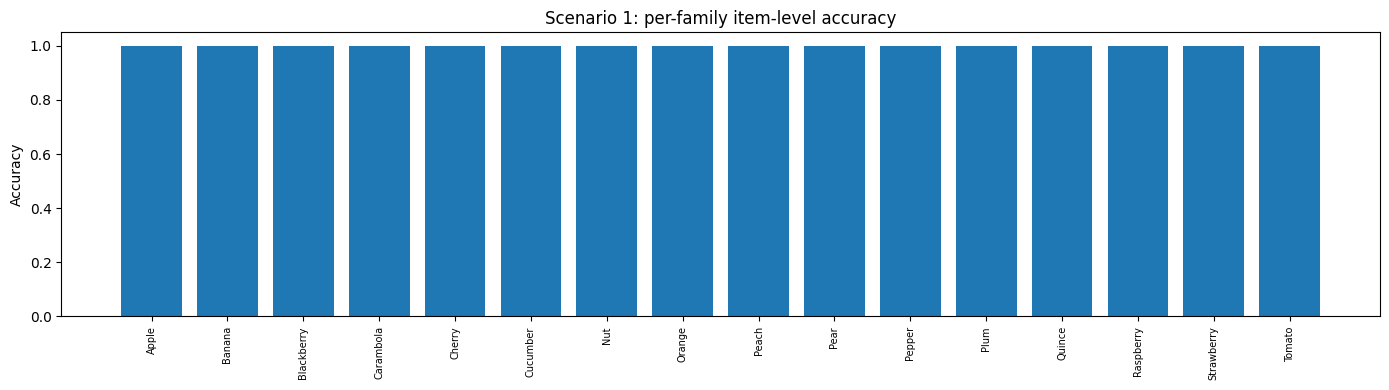

In [11]:
train_embs_s1, train_labels_s1 = get_embeddings(model_t2, train_data)
test_embs_s1,  test_labels_s1  = get_embeddings(model_t2, test_data)
acc_s1 = nn_accuracy(test_embs_s1, test_labels_s1, train_embs_s1, train_labels_s1)
print(f"Scenario 1 accuracy: {acc_s1:.4f}")

label_to_fam = {train_data.item_to_idx[it]: train_data.item_to_family[it] for it in train_data.items}
preds_s1 = [train_labels_s1[i] for i in torch.cdist(test_embs_s1, train_embs_s1).argmin(dim=1).tolist()]

fam_correct, fam_total = defaultdict(int), defaultdict(int)
for pred, true in zip(preds_s1, test_labels_s1):
    fam = label_to_fam[true]
    fam_correct[fam] += int(pred == true)
    fam_total[fam] += 1

fams = sorted(fam_total)
plt.figure(figsize=(14, 4))
plt.bar(range(len(fams)), [fam_correct[f] / fam_total[f] for f in fams])
plt.xticks(range(len(fams)), fams, rotation=90, fontsize=7)
plt.ylabel("Accuracy")
plt.title("Scenario 1: per-family item-level accuracy")
plt.tight_layout()
plt.show()


Scenario 2 accuracy: 1.0000


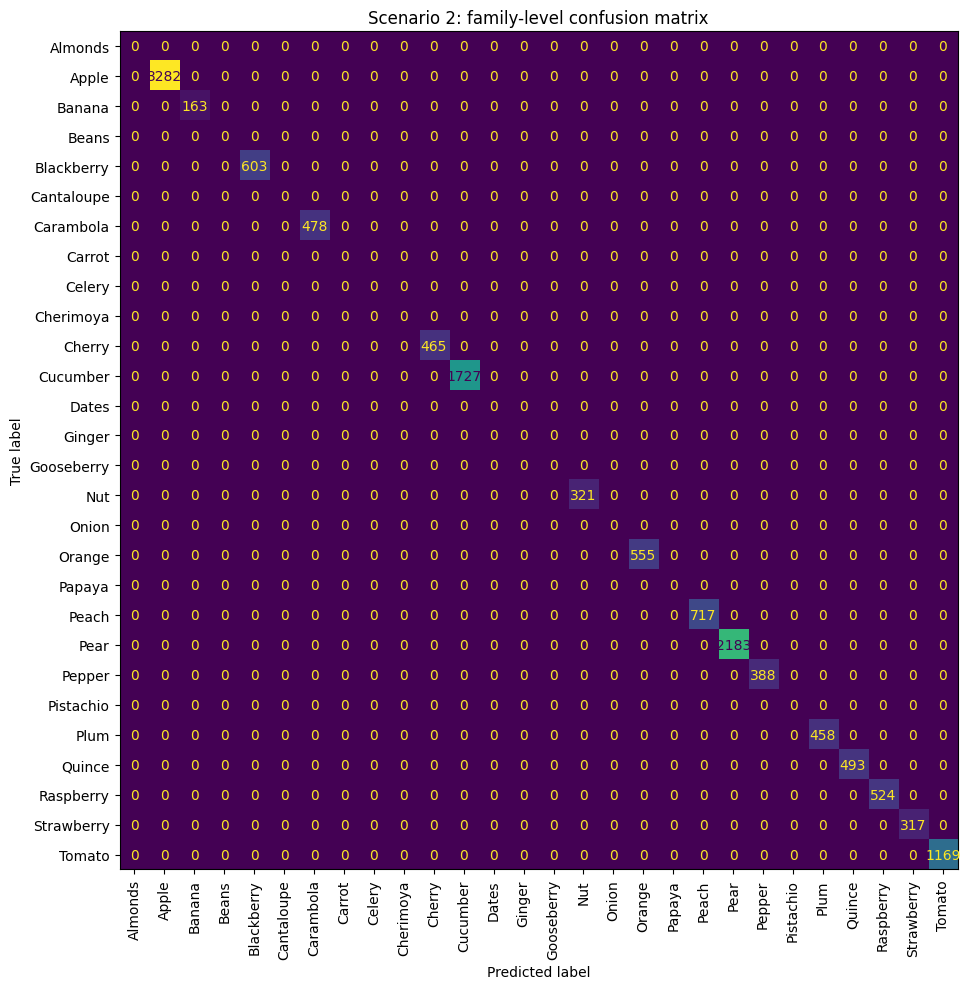

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

train_embs_s2, train_labels_s2 = get_embeddings(model_t2, train_data_family)
test_embs_s2,  test_labels_s2  = get_embeddings(model_t2, test_data_family)
acc_s2 = nn_accuracy(test_embs_s2, test_labels_s2, train_embs_s2, train_labels_s2)
print(f"Scenario 2 accuracy: {acc_s2:.4f}")

preds_s2 = [train_labels_s2[i] for i in torch.cdist(test_embs_s2, train_embs_s2).argmin(dim=1).tolist()]
idx_to_fam = {v: k for k, v in train_data_family.family_to_idx.items()}
labels_sorted = sorted(idx_to_fam)

fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(
    confusion_matrix(test_labels_s2, preds_s2, labels=labels_sorted),
    display_labels=[idx_to_fam[i] for i in labels_sorted]
).plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Scenario 2: family-level confusion matrix")
plt.tight_layout()
plt.show()


In [13]:
support_embs_s3, support_labels_s3 = get_embeddings(model_t2, support_all_data)
test_embs_s3,    test_labels_s3    = get_embeddings(model_t2, test_new_data)
acc_s3 = nn_accuracy(test_embs_s3, test_labels_s3, support_embs_s3, support_labels_s3)
print(f"Scenario 3 accuracy: {acc_s3:.4f}")


Scenario 3 accuracy: 0.9995


In [14]:
support_embs_s4, support_labels_s4 = get_embeddings(model_t2, support_all_data_family)
test_embs_s4,    test_labels_s4    = get_embeddings(model_t2, test_new_data_family)
acc_s4 = nn_accuracy(test_embs_s4, test_labels_s4, support_embs_s4, support_labels_s4)
print(f"Scenario 4 accuracy: {acc_s4:.4f}")


Scenario 4 accuracy: 1.0000


In [ ]:
model_random = EmbeddingCNN(embed_dim=128).to(device)
# no training

rand_embs_train, rand_labels_train = get_embeddings(model_random, train_data)
rand_embs_test,  rand_labels_test  = get_embeddings(model_random, test_data)
acc_random = nn_accuracy(rand_embs_test, rand_labels_test, rand_embs_train, rand_labels_train)
print(f"Random model accuracy scenario 1: {acc_random:.4f}")

Random model accuracy: 0.9999


In [ ]:
rand_embs_train, rand_labels_train = get_embeddings(model_random, train_data_family)
rand_embs_test,  rand_labels_test  = get_embeddings(model_random, test_data_family)
acc_random = nn_accuracy(rand_embs_test, rand_labels_test, rand_embs_train, rand_labels_train)
print(f"Random model accuracy scenario 2: {acc_random:.4f}")

Random model accuracy: 1.0000


In [ ]:
rand_embs_train, rand_labels_train = get_embeddings(model_random, support_all_data)
rand_embs_test,  rand_labels_test  = get_embeddings(model_random, test_new_data)
acc_random = nn_accuracy(rand_embs_test, rand_labels_test, rand_embs_train, rand_labels_train)
print(f"Random model accuracy scenario 3: {acc_random:.4f}")

In [ ]:
rand_embs_train, rand_labels_train = get_embeddings(model_random, support_all_data_family)
rand_embs_test,  rand_labels_test  = get_embeddings(model_random, test_new_data_family)
acc_random = nn_accuracy(rand_embs_test, rand_labels_test, rand_embs_train, rand_labels_train)
print(f"Random model accuracy scenario 4: {acc_random:.4f}")

## Task 3

In [18]:
train_data_both = GardenDataset(class_level="both",transform=transform,subset="train",family_subset="main",item_subset="main")

test_data_both = GardenDataset(class_level="both",transform=transform,subset="test",family_subset="main",item_subset="main")

class FamilyAwareTripletDataset(Dataset):
    def __init__(self, dataset, max_samples=600):
        self.dataset = dataset
        self.item_to_indices = defaultdict(list)
        self.family_to_indices = defaultdict(list)
        self.indices = list(range(len(dataset)))
        if max_samples is not None and len(self.indices) > max_samples:
            random.shuffle(self.indices)
            self.indices = self.indices[:max_samples]
        for idx in self.indices:
            family_label = dataset.targets_family[idx]
            item_label = dataset.targets_item[idx]
            self.item_to_indices[item_label].append(idx)
            self.family_to_indices[family_label].append(idx)
        self.item_labels = list(self.item_to_indices.keys())
        self.family_labels = list(self.family_to_indices.keys())

    def _sample_other(self, indices, exclude_idx=None):
        if exclude_idx is None or len(indices) == 1:
            return random.choice(indices)
        candidates = [idx for idx in indices if idx != exclude_idx]
        return random.choice(candidates) if candidates else random.choice(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        dataset_idx = self.indices[idx]
        anchor_img, anchor_family, anchor_item = self.dataset[dataset_idx]

        pos_item_idx = self._sample_other(self.item_to_indices[anchor_item], exclude_idx=dataset_idx)
        neg_item_label = random.choice([label for label in self.item_labels if label != anchor_item])
        neg_item_idx = random.choice(self.item_to_indices[neg_item_label])

        neg_family_label = random.choice([label for label in self.family_labels if label != anchor_family])
        neg_family_idx = random.choice(self.family_to_indices[neg_family_label])

        pos_item_img, _, _ = self.dataset[pos_item_idx]
        neg_item_img, _, _ = self.dataset[neg_item_idx]
        neg_family_img, _, _ = self.dataset[neg_family_idx]

        return anchor_img, pos_item_img, neg_item_img, neg_family_img


class FamilyAwareTripletLoss(nn.Module):
    def __init__(self, margin=0.5, family_weight=0.5, swap=True):
        super().__init__()
        self.item_loss = nn.TripletMarginLoss(margin=margin, swap=swap)
        self.family_loss = nn.TripletMarginLoss(margin=margin, swap=swap)
        self.family_weight = family_weight

    def forward(self, anchor, pos_item, neg_item, pos_family, neg_family):
        item_term = self.item_loss(anchor, pos_item, neg_item)
        family_term = self.family_loss(anchor, pos_family, neg_family)
        return item_term + self.family_weight * family_term


model_t2 = EmbeddingCNN(embed_dim=128).to(device)
optimizer_t2 = torch.optim.Adam(model_t2.parameters(), lr=1e-3)
criterion_t2 = FamilyAwareTripletLoss(margin=0.5, family_weight=0.5, swap=True)
loader_t2 = DataLoader(FamilyAwareTripletDataset(train_data_both), batch_size=8, shuffle=True)

for epoch in range(5):
    model_t2.train()
    total_loss = 0
    for a, p_item, n_item, n_family in loader_t2:
        a = a.to(device)
        p_item = p_item.to(device)
        n_item = n_item.to(device)
        n_family = n_family.to(device)

        loss = criterion_t2(
            model_t2(a),
            model_t2(p_item),
            model_t2(n_item),
            model_t2(p_item),
            model_t2(n_family),
        )
        optimizer_t2.zero_grad()
        loss.backward()
        optimizer_t2.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1:2d} | loss: {total_loss/len(loader_t2):.4f}")

Epoch  1 | loss: 0.1804
Epoch  2 | loss: 0.1427
Epoch  3 | loss: 0.1485
Epoch  4 | loss: 0.1281
Epoch  5 | loss: 0.1046


Scenario 1 accuracy: 0.9996


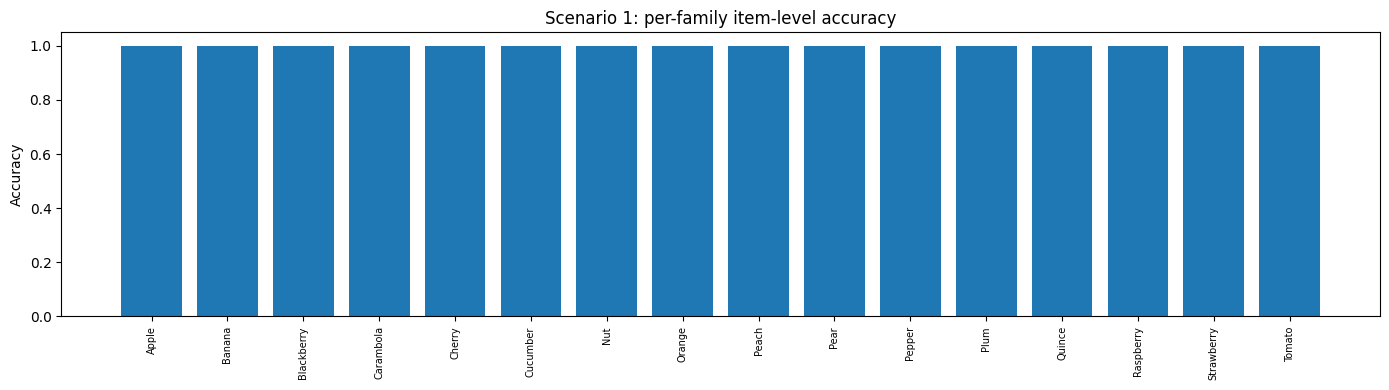

Scenario 2 accuracy: 0.9999


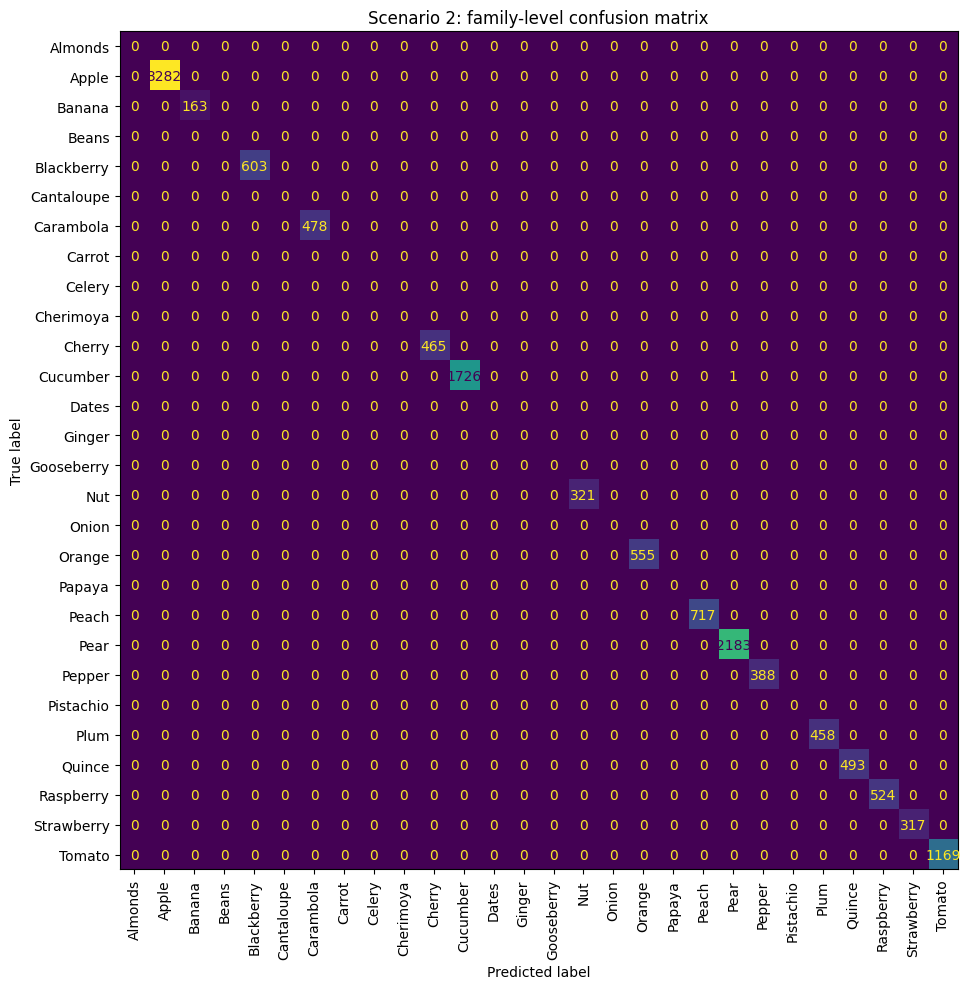

Scenario 3 accuracy: 1.0000
Scenario 4 accuracy: 1.0000


In [19]:
train_embs_s1, train_labels_s1 = get_embeddings(model_t2, train_data)
test_embs_s1,  test_labels_s1  = get_embeddings(model_t2, test_data)
acc_s1 = nn_accuracy(test_embs_s1, test_labels_s1, train_embs_s1, train_labels_s1)
print(f"Scenario 1 accuracy: {acc_s1:.4f}")

label_to_fam = {train_data.item_to_idx[it]: train_data.item_to_family[it] for it in train_data.items}
preds_s1 = [train_labels_s1[i] for i in torch.cdist(test_embs_s1, train_embs_s1).argmin(dim=1).tolist()]

fam_correct, fam_total = defaultdict(int), defaultdict(int)
for pred, true in zip(preds_s1, test_labels_s1):
    fam = label_to_fam[true]
    fam_correct[fam] += int(pred == true)
    fam_total[fam] += 1

fams = sorted(fam_total)
plt.figure(figsize=(14, 4))
plt.bar(range(len(fams)), [fam_correct[f] / fam_total[f] for f in fams])
plt.xticks(range(len(fams)), fams, rotation=90, fontsize=7)
plt.ylabel("Accuracy")
plt.title("Scenario 1: per-family item-level accuracy")
plt.tight_layout()
plt.show()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


train_embs_s2, train_labels_s2 = get_embeddings(model_t2, train_data_family)
test_embs_s2,  test_labels_s2  = get_embeddings(model_t2, test_data_family)
acc_s2 = nn_accuracy(test_embs_s2, test_labels_s2, train_embs_s2, train_labels_s2)
print(f"Scenario 2 accuracy: {acc_s2:.4f}")

preds_s2 = [train_labels_s2[i] for i in torch.cdist(test_embs_s2, train_embs_s2).argmin(dim=1).tolist()]
idx_to_fam = {v: k for k, v in train_data_family.family_to_idx.items()}
labels_sorted = sorted(idx_to_fam)

fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(
    confusion_matrix(test_labels_s2, preds_s2, labels=labels_sorted),
    display_labels=[idx_to_fam[i] for i in labels_sorted]
).plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Scenario 2: family-level confusion matrix")
plt.tight_layout()
plt.show()


support_embs_s3, support_labels_s3 = get_embeddings(model_t2, support_all_data)
test_embs_s3,    test_labels_s3    = get_embeddings(model_t2, test_new_data)
acc_s3 = nn_accuracy(test_embs_s3, test_labels_s3, support_embs_s3, support_labels_s3)
print(f"Scenario 3 accuracy: {acc_s3:.4f}")

support_embs_s4, support_labels_s4 = get_embeddings(model_t2, support_all_data_family)
test_embs_s4,    test_labels_s4    = get_embeddings(model_t2, test_new_data_family)
acc_s4 = nn_accuracy(test_embs_s4, test_labels_s4, support_embs_s4, support_labels_s4)
print(f"Scenario 4 accuracy: {acc_s4:.4f}")

In [ ]:
class FamilyAwareTripletDataset(Dataset):
    def __init__(self, dataset, max_samples=800):
        self.dataset = dataset
        self.indices = list(range(len(dataset)))
        if max_samples is not None and len(self.indices) > max_samples:
            random.shuffle(self.indices)
            self.indices = self.indices[:max_samples]

        self.item_to_indices = defaultdict(list)
        self.family_to_indices = defaultdict(list)
        for idx in self.indices:
            family_label = dataset.targets_family[idx]
            item_label = dataset.targets_item[idx]
            self.item_to_indices[item_label].append(idx)
            self.family_to_indices[family_label].append(idx)

        self.item_labels = list(self.item_to_indices.keys())
        self.family_labels = list(self.family_to_indices.keys())

    def _sample_different(self, candidates, exclude_idx):
        filtered = [idx for idx in candidates if idx != exclude_idx]
        return random.choice(filtered) if filtered else random.choice(candidates)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        anchor_idx = self.indices[idx]
        anchor_img, anchor_family, anchor_item = self.dataset[anchor_idx]

        pos_item_idx = self._sample_different(self.item_to_indices[anchor_item], anchor_idx)
        neg_item_label = random.choice([label for label in self.item_labels if label != anchor_item])
        neg_item_idx = random.choice(self.item_to_indices[neg_item_label])

        pos_family_idx = self._sample_different(self.family_to_indices[anchor_family], anchor_idx)
        neg_family_label = random.choice([label for label in self.family_labels if label != anchor_family])
        neg_family_idx = random.choice(self.family_to_indices[neg_family_label])

        pos_item_img, _, _ = self.dataset[pos_item_idx]
        neg_item_img, _, _ = self.dataset[neg_item_idx]
        pos_family_img, _, _ = self.dataset[pos_family_idx]
        neg_family_img, _, _ = self.dataset[neg_family_idx]

        return anchor_img, pos_item_img, neg_item_img, pos_family_img, neg_family_img


class FamilyAwareTripletLoss(nn.Module):
    def __init__(self, margin=0.5, family_weight=0.5, swap=True):
        super().__init__()
        self.item_loss = nn.TripletMarginLoss(margin=margin, swap=swap)
        self.family_loss = nn.TripletMarginLoss(margin=margin, swap=swap)
        self.family_weight = family_weight

    def forward(self, anchor, pos_item, neg_item, pos_family, neg_family):
        item_term = self.item_loss(anchor, pos_item, neg_item)
        family_term = self.family_loss(anchor, pos_family, neg_family)
        return item_term + self.family_weight * family_term


model_t3_family = EmbeddingCNN(embed_dim=128).to(device)
optimizer_t3_family = torch.optim.Adam(model_t3_family.parameters(), lr=1e-3)
criterion_t3_family = FamilyAwareTripletLoss(margin=0.5, family_weight=0.5, swap=True)
loader_t3_family = DataLoader(FamilyAwareTripletDataset(train_data_both), batch_size=16, shuffle=True)

model_t3_family.train()
total_loss = 0.0
for a, p_item, n_item, p_family, n_family in loader_t3_family:
    a = a.to(device)
    p_item = p_item.to(device)
    n_item = n_item.to(device)
    p_family = p_family.to(device)
    n_family = n_family.to(device)

    loss = criterion_t3_family(
        model_t3_family(a),
        model_t3_family(p_item),
        model_t3_family(n_item),
        model_t3_family(p_family),
        model_t3_family(n_family),
    )
    optimizer_t3_family.zero_grad()
    loss.backward()
    optimizer_t3_family.step()
    total_loss += loss.item()

print(f"Task 3 family-aware loss after 1 epoch: {total_loss / len(loader_t3_family):.4f}")

family_train_embs, family_train_labels = get_embeddings(model_t3_family, train_data_family)
family_test_embs, family_test_labels = get_embeddings(model_t3_family, test_data_family)
family_acc = nn_accuracy(family_test_embs, family_test_labels, family_train_embs, family_train_labels)
print(f"Task 3 family-level accuracy: {family_acc:.4f}")

In [ ]:
train_embs_t3_s1, train_labels_t3_s1 = get_embeddings(model_t3_family, train_data)
test_embs_t3_s1,  test_labels_t3_s1  = get_embeddings(model_t3_family, test_data)
acc_t3_s1 = nn_accuracy(test_embs_t3_s1, test_labels_t3_s1, train_embs_t3_s1, train_labels_t3_s1)
print(f"Task 3 Scenario 1 accuracy: {acc_t3_s1:.4f}")

label_to_fam_t3 = {train_data.item_to_idx[it]: train_data.item_to_family[it] for it in train_data.items}
preds_t3_s1 = [train_labels_t3_s1[i] for i in torch.cdist(test_embs_t3_s1, train_embs_t3_s1).argmin(dim=1).tolist()]

fam_correct_t3, fam_total_t3 = defaultdict(int), defaultdict(int)
for pred, true in zip(preds_t3_s1, test_labels_t3_s1):
    fam = label_to_fam_t3[true]
    fam_correct_t3[fam] += int(pred == true)
    fam_total_t3[fam] += 1

fams_t3 = sorted(fam_total_t3)
plt.figure(figsize=(14, 4))
plt.bar(range(len(fams_t3)), [fam_correct_t3[f] / fam_total_t3[f] for f in fams_t3])
plt.xticks(range(len(fams_t3)), fams_t3, rotation=90, fontsize=7)
plt.ylabel("Accuracy")
plt.title("Task 3 Scenario 1: per-family item-level accuracy")
plt.tight_layout()
plt.show()

train_embs_t3_s2, train_labels_t3_s2 = get_embeddings(model_t3_family, train_data_family)
test_embs_t3_s2,  test_labels_t3_s2  = get_embeddings(model_t3_family, test_data_family)
acc_t3_s2 = nn_accuracy(test_embs_t3_s2, test_labels_t3_s2, train_embs_t3_s2, train_labels_t3_s2)
print(f"Task 3 Scenario 2 accuracy: {acc_t3_s2:.4f}")

preds_t3_s2 = [train_labels_t3_s2[i] for i in torch.cdist(test_embs_t3_s2, train_embs_t3_s2).argmin(dim=1).tolist()]
idx_to_fam_t3 = {v: k for k, v in train_data_family.family_to_idx.items()}
labels_sorted_t3 = sorted(idx_to_fam_t3)

fig, ax = plt.subplots(figsize=(12, 10))
cm_t3 = torch.zeros((len(labels_sorted_t3), len(labels_sorted_t3)), dtype=torch.int64)
label_to_pos_t3 = {label: i for i, label in enumerate(labels_sorted_t3)}
for true_label, pred_label in zip(test_labels_t3_s2, preds_t3_s2):
    cm_t3[label_to_pos_t3[true_label], label_to_pos_t3[pred_label]] += 1
im = ax.imshow(cm_t3.numpy(), cmap="Blues")
ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(len(labels_sorted_t3)))
ax.set_yticks(range(len(labels_sorted_t3)))
ax.set_xticklabels([idx_to_fam_t3[i] for i in labels_sorted_t3], rotation=90)
ax.set_yticklabels([idx_to_fam_t3[i] for i in labels_sorted_t3])
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.title("Task 3 Scenario 2: family-level confusion matrix")
plt.tight_layout()
plt.show()

support_embs_t3_s3, support_labels_t3_s3 = get_embeddings(model_t3_family, support_all_data)
test_embs_t3_s3,    test_labels_t3_s3    = get_embeddings(model_t3_family, test_new_data)
acc_t3_s3 = nn_accuracy(test_embs_t3_s3, test_labels_t3_s3, support_embs_t3_s3, support_labels_t3_s3)
print(f"Task 3 Scenario 3 accuracy: {acc_t3_s3:.4f}")

support_embs_t3_s4, support_labels_t3_s4 = get_embeddings(model_t3_family, support_all_data_family)
test_embs_t3_s4,    test_labels_t3_s4    = get_embeddings(model_t3_family, test_new_data_family)
acc_t3_s4 = nn_accuracy(test_embs_t3_s4, test_labels_t3_s4, support_embs_t3_s4, support_labels_t3_s4)
print(f"Task 3 Scenario 4 accuracy: {acc_t3_s4:.4f}")

## Task 4

In [20]:
class BlackoutPixels:
    """Transform that randomly sets x% of pixels to black (0).
    
    Args:
        fraction: Fraction of pixels to black out (0.0 to 1.0).
    """
    def __init__(self, fraction=0.1):
        self.fraction = fraction

    def __call__(self, img):
        # img shape: (C, H, W)
        _, h, w = img.shape
        num_pixels = h * w
        num_black = int(num_pixels * self.fraction)

        # Random pixel indices to black out
        indices = torch.randperm(num_pixels)[:num_black]
        rows = indices // w
        cols = indices % w

        img = img.clone()
        img[:, rows, cols] = 0.0
        return img

def get_anomaly_dataset(fraction):
    transform = transforms.Compose([
        BlackoutPixels(fraction=fraction),
        ... # your transforms here
    ])
    return GardenDataset(subset="test", transform=transform, family_subset="main", item_subset="main")

# your code here
